# PyTorch Lab — Tasks

Source: DS_MLL_Lab_06__PyTorch.pdf

This notebook contains the lab tasks extracted from the original PDF. Each task is presented as a clear, focused description with an explicit `Your code` placeholder where you can add code cells.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
from torch.nn import MSELoss
from torch.optim import SGD
import matplotlib.pyplot as plt

## Table of Contents

1. Linear model and training loop
2. MNIST dataset: load and preprocessing
3. Multi-layer neural network (SimpleNN)
4. Training & evaluation for classification
5. Experiments and extensions

## 1. Linear model and training loop

### Instructions

- Implement a simple linear model for regression/classification using `torch.nn.Linear`.
- Use `MSELoss` (regression) or `CrossEntropyLoss` (classification) as appropriate.
- Use Stochastic Gradient Descent (SGD) with learning rate 0.01 and momentum 0.9.
- Implement the full training loop: forward pass, loss computation, backward pass, optimizer step, and gradient reset.
- Track and plot training loss over epochs; optionally record weight and bias values to inspect learning dynamics.

### Hints / Notes

- Call `model.train()` before training and `optimizer.zero_grad()` at the start of each batch.
- Use `loss.item()` to record scalar loss values for plotting.

### Your Code

Add your code for this task in a new code cell below.

In [2]:
sample_dataset = torch.randn(2048, 1)
y =  sample_dataset * 5 + 3 + torch.randn(2048, 1) * 0.001
TensorDataset = torch.utils.data.TensorDataset(sample_dataset, y)
x, y = TensorDataset[0]
print(f"First sample - x: {x}, y: {y}")
print(f"Total number of samples in dataset: {len(sample_dataset)}")

First sample - x: tensor([0.2956]), y: tensor([4.4762])
Total number of samples in dataset: 2048


In [3]:
dataloader = DataLoader(TensorDataset, batch_size=32, shuffle=True)
for i, (inputs, targets) in enumerate(dataloader):
    print(f"Batch {i} - inputs: {inputs.reshape(-1)[:3]}, targets: {targets.reshape(-1)[:3]}")
    print(f"Batch {i} - inputs shape: {inputs.shape}, targets shape: {targets.shape}")
    if i == 2: 
        break

Batch 0 - inputs: tensor([-0.6338,  2.0877, -0.5282]), targets: tensor([-0.1696, 13.4378,  0.3590])
Batch 0 - inputs shape: torch.Size([32, 1]), targets shape: torch.Size([32, 1])
Batch 1 - inputs: tensor([ 0.4770, -1.6628, -1.1798]), targets: tensor([ 5.3854, -5.3135, -2.8981])
Batch 1 - inputs shape: torch.Size([32, 1]), targets shape: torch.Size([32, 1])
Batch 2 - inputs: tensor([-0.1538, -0.1150,  0.9297]), targets: tensor([2.2295, 2.4236, 7.6472])
Batch 2 - inputs shape: torch.Size([32, 1]), targets shape: torch.Size([32, 1])


In [4]:
class SimpleLinearModel(torch.nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.linear_layer = torch.nn.Linear(in_features=input_size, out_features=output_size)

    def forward(self, x):
        return self.linear_layer(x)
    
model = SimpleLinearModel(input_size=1, output_size=1)



In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"The device is set to: {device}")
model = model.to(device)

The device is set to: cuda


f:\Practices\MyRandomMLPractices\.venv\lib\site-packages\torch\cuda\__init__.py:287: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


Epoch 1/50, Loss: 13.6746
Epoch 2/50, Loss: 0.9448
Epoch 3/50, Loss: 0.0653
Epoch 4/50, Loss: 0.0045
Epoch 5/50, Loss: 0.0003
Epoch 6/50, Loss: 0.0000
Epoch 7/50, Loss: 0.0000
Epoch 8/50, Loss: 0.0000
Epoch 9/50, Loss: 0.0000
Epoch 10/50, Loss: 0.0000
Epoch 11/50, Loss: 0.0000
Epoch 12/50, Loss: 0.0000
Epoch 13/50, Loss: 0.0000
Epoch 14/50, Loss: 0.0000
Epoch 15/50, Loss: 0.0000
Epoch 16/50, Loss: 0.0000
Epoch 17/50, Loss: 0.0000
Epoch 18/50, Loss: 0.0000
Epoch 19/50, Loss: 0.0000
Epoch 20/50, Loss: 0.0000
Epoch 21/50, Loss: 0.0000
Epoch 22/50, Loss: 0.0000
Epoch 23/50, Loss: 0.0000
Epoch 24/50, Loss: 0.0000
Epoch 25/50, Loss: 0.0000
Epoch 26/50, Loss: 0.0000
Epoch 27/50, Loss: 0.0000
Epoch 28/50, Loss: 0.0000
Epoch 29/50, Loss: 0.0000
Epoch 30/50, Loss: 0.0000
Epoch 31/50, Loss: 0.0000
Epoch 32/50, Loss: 0.0000
Epoch 33/50, Loss: 0.0000
Epoch 34/50, Loss: 0.0000
Epoch 35/50, Loss: 0.0000
Epoch 36/50, Loss: 0.0000
Epoch 37/50, Loss: 0.0000
Epoch 38/50, Loss: 0.0000
Epoch 39/50, Loss: 0

<Figure size 1200x400 with 0 Axes>

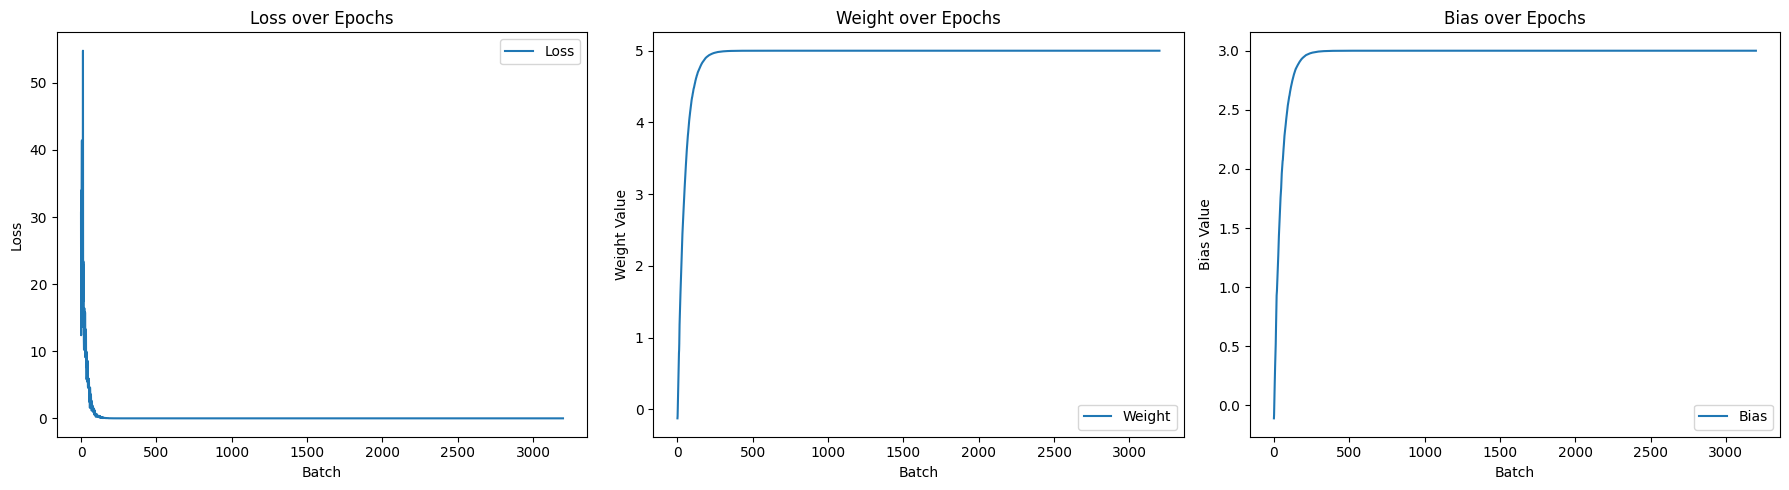

In [6]:
num_epochs = 50
losses, weights, biases = [], [], []

optimizer = SGD(model.parameters(), lr=0.01)
criterion = MSELoss()

for epoch in range(num_epochs):
    running_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        weights.append(model.linear_layer.weight.item())
        biases.append(model.linear_layer.bias.item())
        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(dataloader):.4f}")

plt.figure(figsize=(12, 4))
plt.subplots(1, 3, figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.plot(losses, label='Loss')
plt.title('Loss over Epochs')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 3, 2)
plt.plot(weights, label='Weight')
plt.title('Weight over Epochs')
plt.xlabel('Batch')
plt.ylabel('Weight Value')
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(biases, label='Bias')
plt.title('Bias over Epochs')
plt.xlabel('Batch')
plt.ylabel('Bias Value')
plt.legend()
plt.tight_layout()

In [7]:
weights = model.linear_layer.weight.detach().cpu()
biases = model.linear_layer.bias.detach().cpu()

print(f'Learned weights: {weights}')
print(f'Learned biases: {biases}')

Learned weights: tensor([[5.0000]])
Learned biases: tensor([3.0000])


## 2. MNIST dataset: load and preprocessing

### Instructions

- Load MNIST using `torchvision.datasets.MNIST` (use `download=True` if needed).
- Inspect dataset sizes and sample structure (image shape and label).
- Define a transform pipeline: `transforms.ToTensor()` and normalization with `mean=0.1307`, `std=0.3081`.
- (Optional) Add simple data augmentations (e.g., small random rotations) and visualize transformed samples.

### Hints / Notes

- Verify that transformed images have shape `[1, 28, 28]` and pixel values in [0,1].
- Assign the transform to `train_dataset.transform` if dataset was loaded without transforms.

### Your Code

Add your code for this task in a new code cell below.

In [8]:
train_dataset= MNIST(root="data",train=True,download=True)
test_dataset= MNIST(root="data",train=False,download=True)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 60000
Number of test samples: 10000


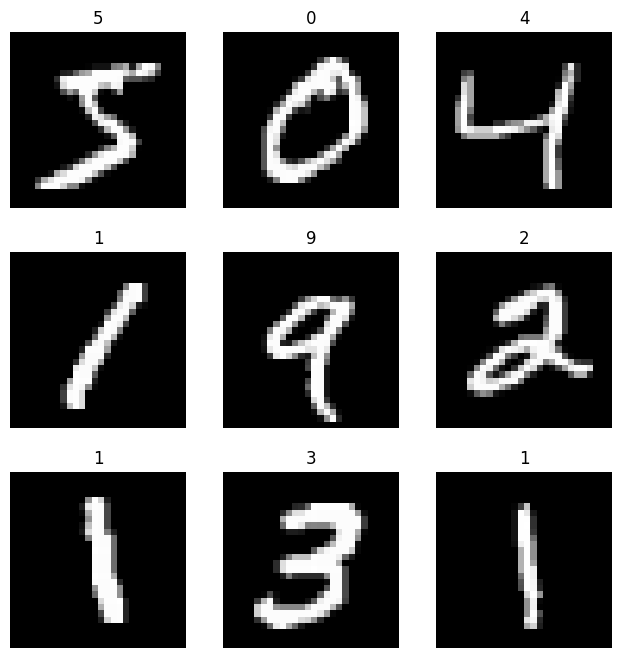

In [9]:
fig, ax = plt.subplots(3, 3, figsize=(8, 8))
plt.subplots_adjust(hspace=0.25, wspace=0.1)

for i in range(3):
    for j in range(3):
        idx = i * 3 + j
        img, label = train_dataset[idx]

        ax[i, j].imshow(img, cmap='gray')     
        ax[i, j].set_title(label)
        ax[i, j].axis('off')

In [10]:
mean, std = train_dataset.data.float().mean()/255, train_dataset.data.float().std()/255
print(f"Mean: {mean}, Std: {std}")


Mean: 0.13066047430038452, Std: 0.30810779333114624


In [13]:
normalize = transforms.Normalize(mean, std)
transform = transforms.Compose([transforms.RandomRotation(45), transforms.ToTensor(), normalize])
train_dataset.transform = transform 
test_dataset.transform = transform

image, label = train_dataset[0]
print(f"Image shape: {image.shape}, Label: {label}")
print(f"Image tensor - min: {image.min()}, max: {image.max()}, mean: {image.mean():.4f}, std: {image.std():.4f}")

Image shape: torch.Size([1, 28, 28]), Label: 5
Image tensor - min: -0.4240739047527313, max: 2.8215434551239014, mean: 0.0288, std: 1.0246


## 3. Multi-layer neural network (SimpleNN)

### Instructions

- Define `SimpleNN` as a subclass of `nn.Module` with three `nn.Linear` layers:
  - Input: flattened 28×28 (784) features
  - Hidden1: 512 units (ReLU), Hidden2: 256 units (ReLU), Output: 10 units (logits).
- Implement the `forward()` method (flatten input, apply layers + ReLU, return logits).

### Hints / Notes

- Use `x.view(x.size(0), -1)` or `torch.flatten(x, 1)` to flatten while preserving batch size.

### Your Code

Add your code for this task in a new code cell below.

In [27]:
class SimpleNN(torch.nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = torch.nn.Linear(in_features=input_size, out_features=512)
        self.fc2 = torch.nn.Linear(in_features=512, out_features=256)
        self.fc3 = torch.nn.Linear(in_features=256, out_features=10)
        self.relu = torch.nn.ReLU()
    def forward(self,x):
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x


## 4. Training & evaluation for classification

### Instructions

- Create `DataLoader` objects for training and test sets (e.g., `batch_size=1024`, `shuffle=True` for training).
- Initialize model, move to device (CPU/GPU), set loss to `CrossEntropyLoss`, and optimizer to SGD (lr=0.01, momentum=0.9).
- Implement a validation function that computes accuracy on the test set using `model.eval()` and `torch.no_grad()`.
- Train the model for a fixed number of epochs (e.g., 5) and print test accuracy after training.

### Hints / Notes

- In evaluation, call `model.eval()` and wrap inference in `with torch.no_grad():` to disable gradients.
- Use `torch.max(outputs, 1)` or `outputs.argmax(dim=1)` to obtain predicted classes.

### Your Code

Add your code for this task in a new code cell below.

In [31]:
train_dataloader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
validation_dataloader = DataLoader(test_dataset, batch_size=1024, shuffle=False)
Model  = SimpleNN(input_size=28*28)
Model = Model.to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(Model.parameters(), lr=0.01, momentum=0.9)
num_epochs = 50
for epoch in range(num_epochs):
    for i, (inputs, targets) in enumerate(train_dataloader):
        inputs, targets = inputs.to(device), targets.to(device)
        Model.zero_grad()
        outputs = Model.forward(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
    validation_loss = 0.0
    with torch.no_grad():
        for inputs, targets in validation_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = Model(inputs)
            loss = criterion(outputs, targets)
            validation_loss += loss.item()
            accuracy = (outputs.argmax(dim=1) == targets).float().mean().item()
    print(f"Epoch {epoch+1}/{num_epochs}, Validation Loss: {validation_loss/len(validation_dataloader):.4f}, Validation Accuracy: {accuracy:.4f}")

Epoch 1/50, Validation Loss: 1.7644, Validation Accuracy: 0.5319
Epoch 2/50, Validation Loss: 1.3895, Validation Accuracy: 0.5893
Epoch 3/50, Validation Loss: 1.2524, Validation Accuracy: 0.6339
Epoch 4/50, Validation Loss: 1.0197, Validation Accuracy: 0.7003
Epoch 5/50, Validation Loss: 0.8419, Validation Accuracy: 0.7194
Epoch 6/50, Validation Loss: 0.7368, Validation Accuracy: 0.7717
Epoch 7/50, Validation Loss: 0.6333, Validation Accuracy: 0.8036
Epoch 8/50, Validation Loss: 0.5651, Validation Accuracy: 0.8176
Epoch 9/50, Validation Loss: 0.5319, Validation Accuracy: 0.8138
Epoch 10/50, Validation Loss: 0.5227, Validation Accuracy: 0.8342
Epoch 11/50, Validation Loss: 0.4835, Validation Accuracy: 0.8495
Epoch 12/50, Validation Loss: 0.4642, Validation Accuracy: 0.8546
Epoch 13/50, Validation Loss: 0.4396, Validation Accuracy: 0.8610
Epoch 14/50, Validation Loss: 0.4322, Validation Accuracy: 0.8584
Epoch 15/50, Validation Loss: 0.4011, Validation Accuracy: 0.8635
Epoch 16/50, Valida

## 5. Experiments and extensions

### Instructions

- Try variations and experiments: change learning rate, batch size, add weight decay, or alternate optimizers.
- Implement a deeper network or try different activations.
- (Optional) Implement logging of weight/bias values and plot their evolution.

### Hints / Notes

- Keep experiments isolated: change one hyperparameter at a time to compare effects.

### Your Code

Add your code for this task in a new code cell below.